## Import libraries

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 1) Standard library
import os
import sys
import random
import logging
import warnings
import itertools
from datetime import datetime


# ─────────────────────────────────────────────────────────────────────────────
# 2) Data handling
import pandas as pd
import numpy as np
import yfinance as yf

# ─────────────────────────────────────────────────────────────────────────────
# 3) Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ─────────────────────────────────────────────────────────────────────────────
# 4) Time-series analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# ─────────────────────────────────────────────────────────────────────────────
# 5) Machine learning utilities
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# ─────────────────────────────────────────────────────────────────────────────
# 6) Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Input, LayerNormalization,
    MultiHeadAttention, Dropout, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from prophet import Prophet

# ─────────────────────────────────────────────────────────────────────────────
# 7) Warnings & logging
logging.getLogger().setLevel(logging.WARNING)

for name in ("cmdstanpy", "prophet"):
    logger = logging.getLogger(name)
    logger.setLevel(logging.WARNING)
    logger.propagate = False

logging.getLogger("statsmodels").setLevel(logging.WARNING)
logging.getLogger("urllib3").setLevel(logging.WARNING)


warnings.filterwarnings("ignore")


## Data Download & Evaluation & Data Cleaning

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1) Reproducibility
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# 2) Configuration
TICKERS     = {"AMZN": "Amazon.com, Inc.",
               "MSFT": "Microsoft Corporation",
               "XOM":  "Exxon Mobil Corporation"}
START_DATE  = "2022-01-01"
END_DATE    = "2025-01-01"
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1


# Rolling‐window length for ARIMA fitting. Use None to fit on full train history.
ARIMA_WINDOW = 200

# ─────────────────────────────────────────────────────────────────────────────
# 3) Download all tickers at once
logging.info("Downloading price data for %s", list(TICKERS.keys()))
all_prices = yf.download(
    list(TICKERS.keys()),
    start=START_DATE,
    end=END_DATE
)["Close"]

# ─────────────────────────────────────────────────────────────────────────────
# 4) Evaluation function: MAE, MAPE, directional accuracy
def evaluate_metrics(true, pred):
    mae  = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / np.where(true==0,1e-8,true))) * 100
    rmse = np.sqrt(mean_squared_error(true, pred))
    return mae, mape, rmse

# ─────────────────────────────────────────────────────────────────────────────
# 5) Check for duplicates and missing values

# 5.1) Duplicate dates in the index
dup_index_count = all_prices.index.duplicated().sum()
print(f"Number of duplicate dates in index: {dup_index_count}")

# 5.2) Duplicate rows (all columns identical)
dup_row_count = all_prices.duplicated().sum()
print(f"Number of completely duplicate rows: {dup_row_count}")

# 5.3) Missing values per ticker
missing_per_ticker = all_prices.isnull().sum()
print("Missing values per ticker:")
print(missing_per_ticker)

# 5.4) Total missing values
total_missing = all_prices.isnull().sum().sum()
print(f"Total missing values in DataFrame: {total_missing}")


[*********************100%***********************]  3 of 3 completed

Number of duplicate dates in index: 0
Number of completely duplicate rows: 0
Missing values per ticker:
Ticker
AMZN    0
MSFT    0
XOM     0
dtype: int64
Total missing values in DataFrame: 0


## Outlier Handling


No outliers detected in AMZN.

No outliers detected in MSFT.

Outliers detected in XOM:
Date
2022-01-03    55.607395
2022-01-04    57.699017
2022-01-05    58.416645
2022-01-06    59.790642
2022-01-07    60.280731
2022-01-10    59.921898
2022-01-13    61.812244
Name: XOM, dtype: float64


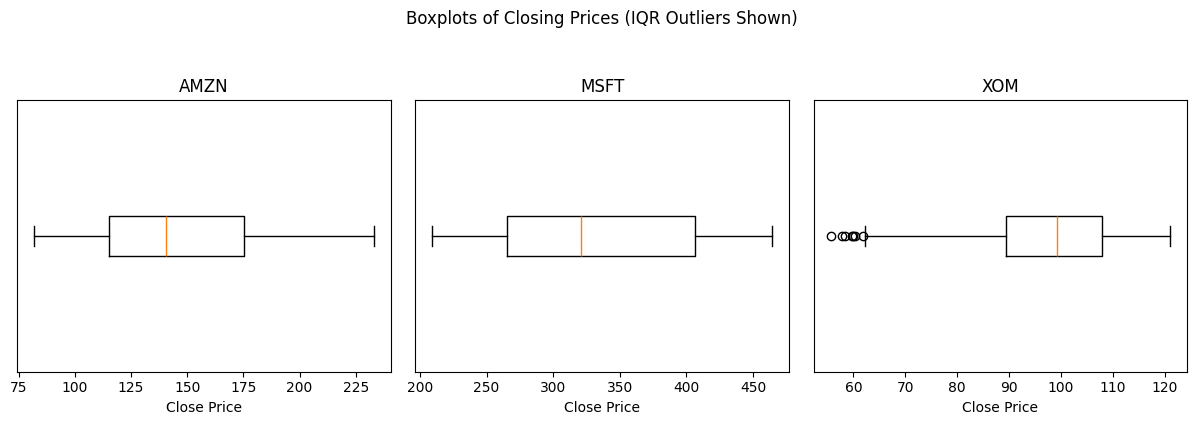


No remaining outliers in AMZN.

No remaining outliers in MSFT.

No remaining outliers in XOM.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 5) Outlier detection via IQR and print results
def detect_outliers_iqr(df):
    """
    Given a DataFrame with tickers as columns,
    returns a boolean DataFrame marking True where the value is an outlier.
    """
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return (df < lower) | (df > upper)

# Apply to the closing prices
outliers = detect_outliers_iqr(all_prices)

# Print outlier info per ticker
for tk in TICKERS:
    mask = outliers[tk]
    if mask.any():
        print(f"\nOutliers detected in {tk}:")
        print(all_prices[tk][mask])
    else:
        print(f"\nNo outliers detected in {tk}.")

# ─────────────────────────────────────────────────────────────────────────────
# 6) Boxplots for each ticker (one row, side-by-side)
fig, axes = plt.subplots(1, len(TICKERS), figsize=(12, 4), sharey=True)
for ax, tk in zip(axes, TICKERS):
    series = all_prices[tk].dropna()
    ax.boxplot(series, vert=False, showfliers=True)
    ax.set_title(f"{tk}")
    ax.set_xlabel("Close Price")
    ax.set_yticks([])

fig.suptitle("Boxplots of Closing Prices (IQR Outliers Shown)", y=1.05)
axes[0].set_ylabel("")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Outlier handling via winsorization (1.5×IQR cap/floor)

# 1) Compute quartiles and IQR on the original all_prices
Q1 = all_prices.quantile(0.25)
Q3 = all_prices.quantile(0.75)
IQR = Q3 - Q1

# 2) Define lower & upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3) Winsorize: clamp all_prices to these bounds
all_prices = all_prices.clip(lower=lower_bound, upper=upper_bound, axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# 7) Verify that outliers have been handled
post_outliers = detect_outliers_iqr(all_prices)

for tk in TICKERS:
    mask = post_outliers[tk]
    if mask.any():
        print(f"\nRemaining outliers in {tk}:")
        print(all_prices[tk][mask])
    else:
        print(f"\nNo remaining outliers in {tk}.")


## Closing Price Comparison

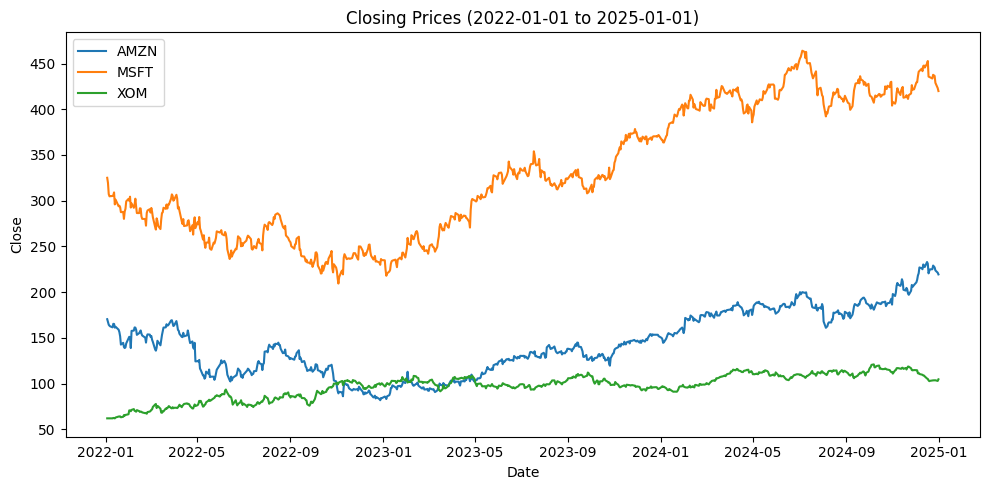

In [4]:
df_plot = all_prices.reset_index().rename(columns={"index":"Date"})
df_plot["Date"] = pd.to_datetime(df_plot["Date"])
mask = (df_plot["Date"] >= pd.to_datetime(START_DATE)) & (df_plot["Date"] <= pd.to_datetime(END_DATE))
df_plot = df_plot.loc[mask]

plt.figure(figsize=(10,5))
for tk in TICKERS:
    series = df_plot[[ "Date", tk ]].set_index("Date")[tk]
    plt.plot(series.index, series.values, label=tk)
plt.title(f"Closing Prices ({START_DATE} to {END_DATE})")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.tight_layout()
plt.show()


# ARIMA

### 1-day prediction


===== AMZN =====
ADF p-value=0.662 → d=1


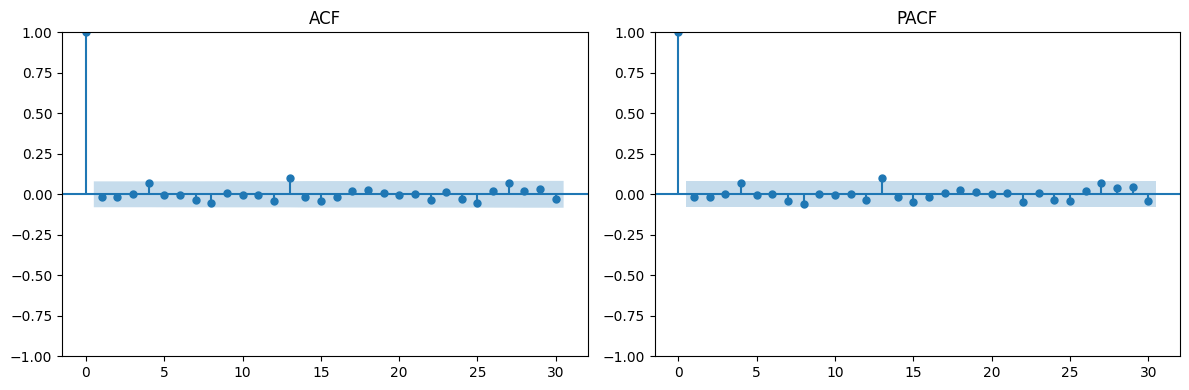

Selected ARIMA order=(3, 1, 3), AIC=3108.2


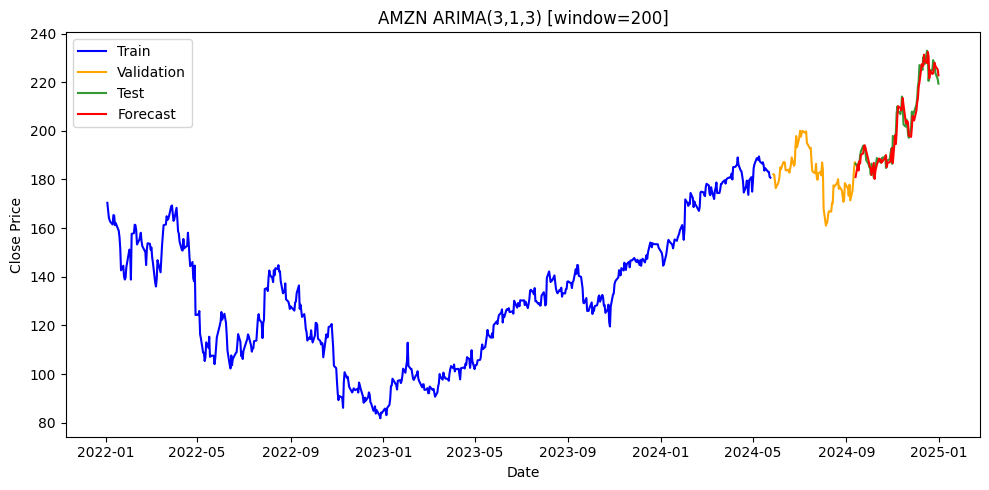

→ MAE: 2.8728, MAPE: 1.42%, RMSE: 3.6688

===== MSFT =====
ADF p-value=0.972 → d=1


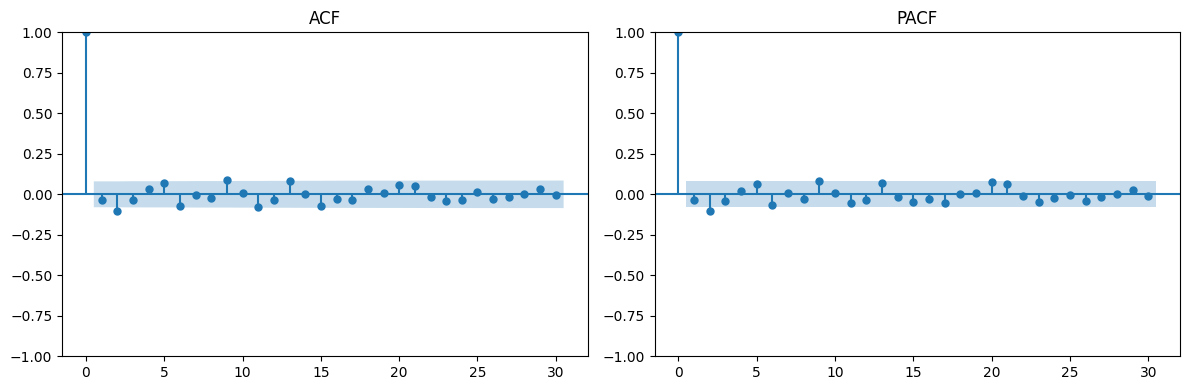

Selected ARIMA order=(2, 1, 3), AIC=3687.1


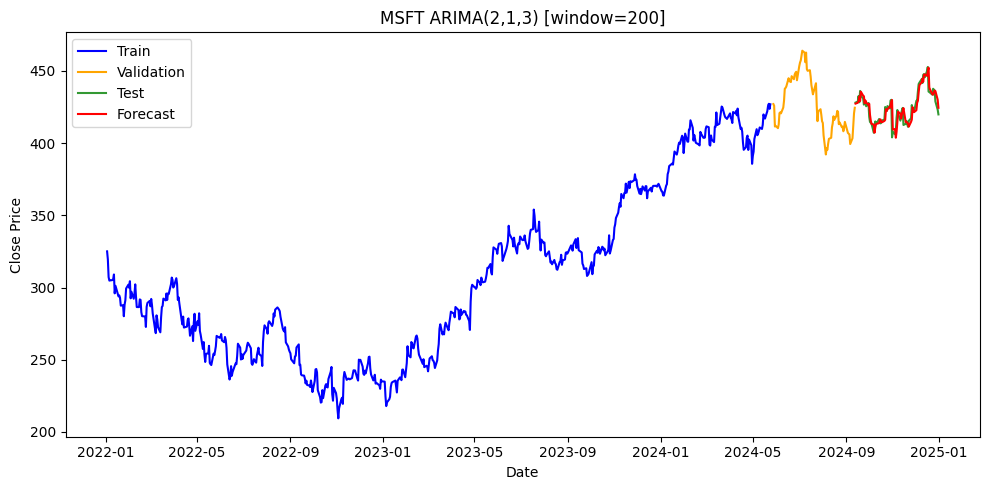

→ MAE: 3.7588, MAPE: 0.89%, RMSE: 5.4647

===== XOM =====
ADF p-value=0.171 → d=1


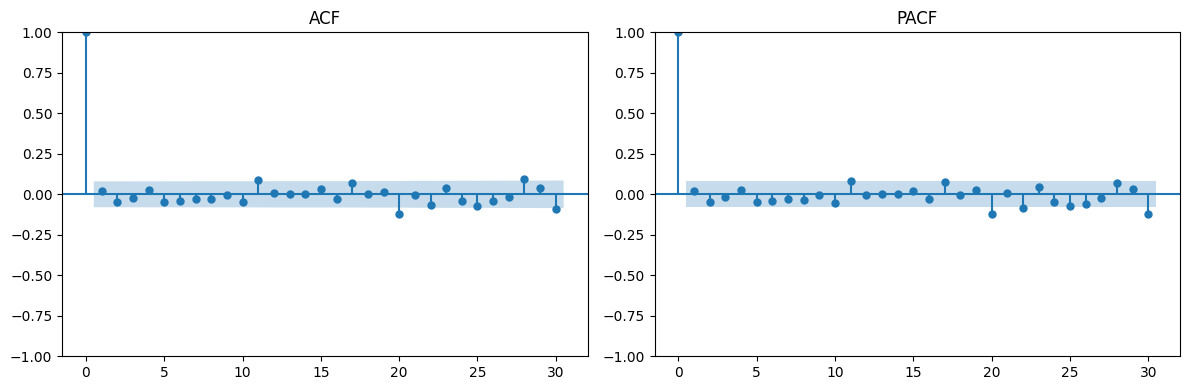

Selected ARIMA order=(2, 1, 2), AIC=2278.2


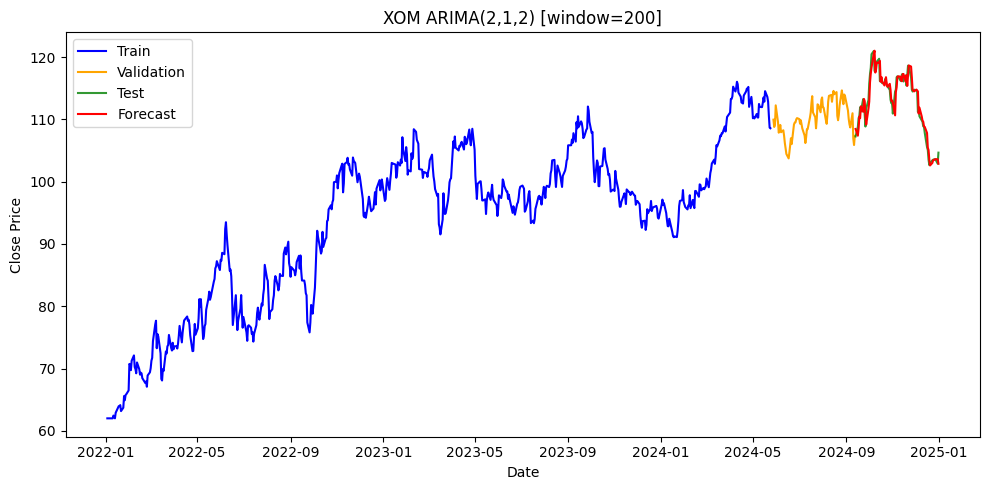

→ MAE: 1.0231, MAPE: 0.91%, RMSE: 1.3640


,MAE,MAPE,RMSE
Ticker,,,
AMZN,2.872832,1.417453,3.668814
MSFT,3.758847,0.888418,5.464731
XOM,1.023059,0.905575,1.363971


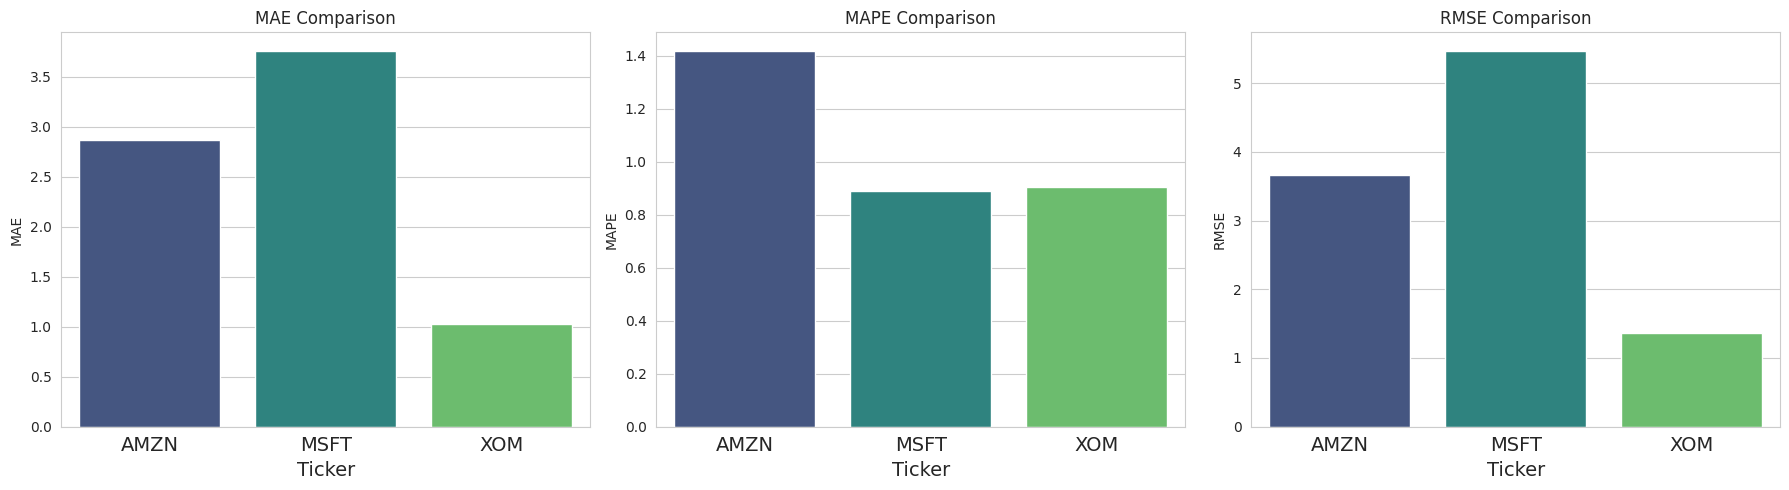

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# ARIMA experiment per ticker
results = []


for tk in TICKERS:
    print(f"\n===== {tk} =====")
    series = all_prices[tk].dropna()
    n       = len(series)
    train_end = int(n * TRAIN_RATIO)
    val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))
    train   = series.iloc[:train_end]
    val     = series.iloc[train_end:val_end]
    test    = series.iloc[val_end:]


    # 1) Determine d via ADF
    pval = adfuller(train)[1]
    d    = 1 if pval > 0.05 else 0
    print(f"ADF p-value={pval:.3f} → d={d}")


    # 2) ACF/PACF
    diff_train = train.diff().dropna() if d == 1 else train
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    plot_acf(diff_train, ax=axes[0], lags=30); axes[0].set_title("ACF")
    plot_pacf(diff_train, ax=axes[1], lags=30); axes[1].set_title("PACF")
    plt.tight_layout(); plt.show()


    # 3) Grid‑search p, q by AIC
    best_aic, best_order = np.inf, None
    for p, q in itertools.product(range(4), range(4)):
        if p==0 and q==0: continue
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                m = ARIMA(train, order=(p,d,q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p,d,q)
        except:
            pass


    p_opt, d_opt, q_opt = best_order
    print(f"Selected ARIMA order={best_order}, AIC={best_aic:.1f}")


    # 4) Rolling‐window slice
    if ARIMA_WINDOW and len(train) > ARIMA_WINDOW:
        history = train.iloc[-ARIMA_WINDOW:].tolist()
    else:
        history = train.tolist()


    # 5) Walk‑forward forecasting
    predictions = []
    for actual in test:
        model = ARIMA(history, order=(p_opt,d_opt,q_opt)).fit()
        yhat  = model.forecast()[0]
        predictions.append(yhat)
        history.append(actual)


    mean_fc = pd.Series(predictions, index=test.index)


    # 6) Plot results (modified to include validation set)
    plt.figure(figsize=(10,5))
    plt.plot(train.index, train, label="Train", color='blue')
    plt.plot(val.index, val, label="Validation", color='orange')
    plt.plot(test.index,  test,  label="Test",  color='green', alpha=0.8)
    plt.plot(test.index,  mean_fc, color='red',  label="Forecast")
    plt.title(f"{tk} ARIMA({p_opt},{d_opt},{q_opt}) [window={ARIMA_WINDOW}]")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.tight_layout(); plt.show()



    # 7) Compute metrics
    mae, mape, rmse = evaluate_metrics(test.values, mean_fc.values)
    print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.4f}")


    results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})


# ─────────────────────────────────────────────────────────────────────────────
# Aggregate & bar plots
res_df = pd.DataFrame(results).set_index("Ticker")
display(res_df)


sns.set_style("whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axs, ["MAE", "MAPE", "RMSE"]):
    sns.barplot(x=res_df.index, y=res_df[metric], palette="viridis", ax=ax)
    ax.set_title(f"{metric} Comparison")
    ax.set_xlabel("Ticker", fontsize=14)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', labelsize=14)
plt.tight_layout()
plt.show()


### 3 days forecasting


===== AMZN =====
ADF p-value=0.662 → d=1


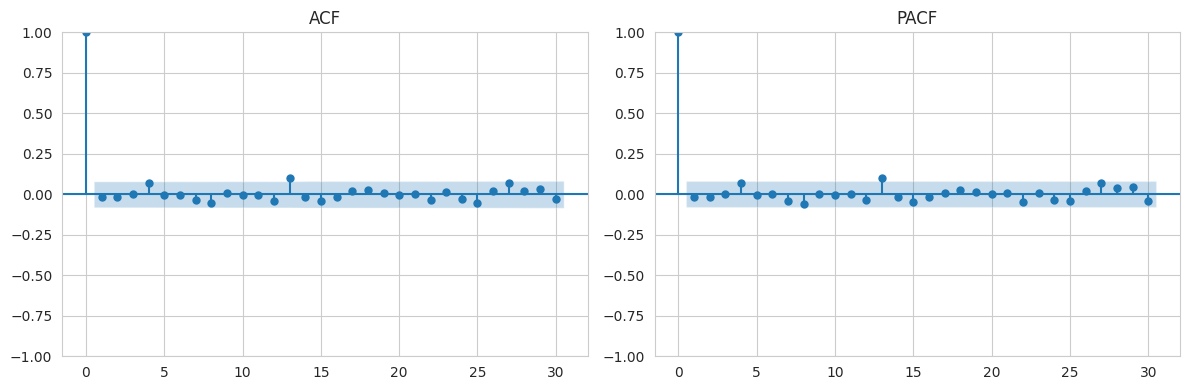

Selected order=(3, 1, 3), AIC=3108.2


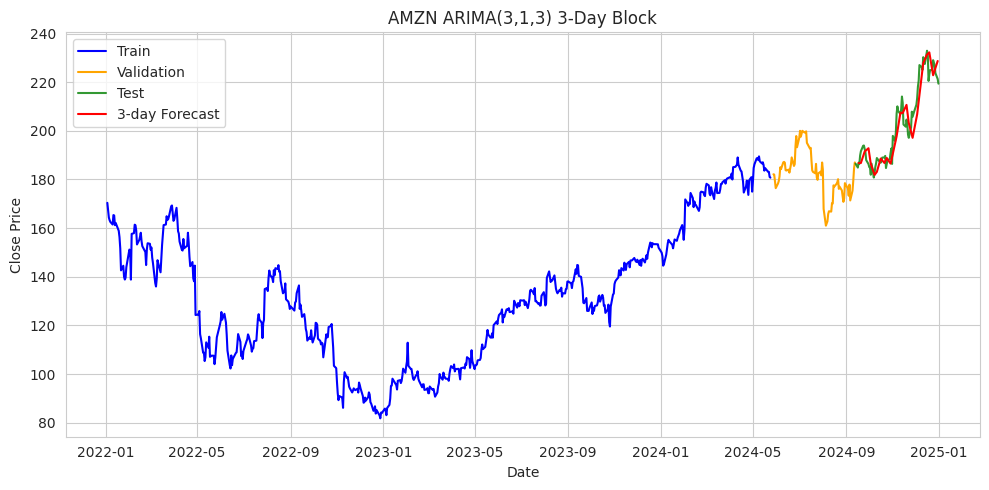

→ MAE: 4.8812, MAPE: 2.37%, RMSE: 5.7874

===== MSFT =====
ADF p-value=0.972 → d=1


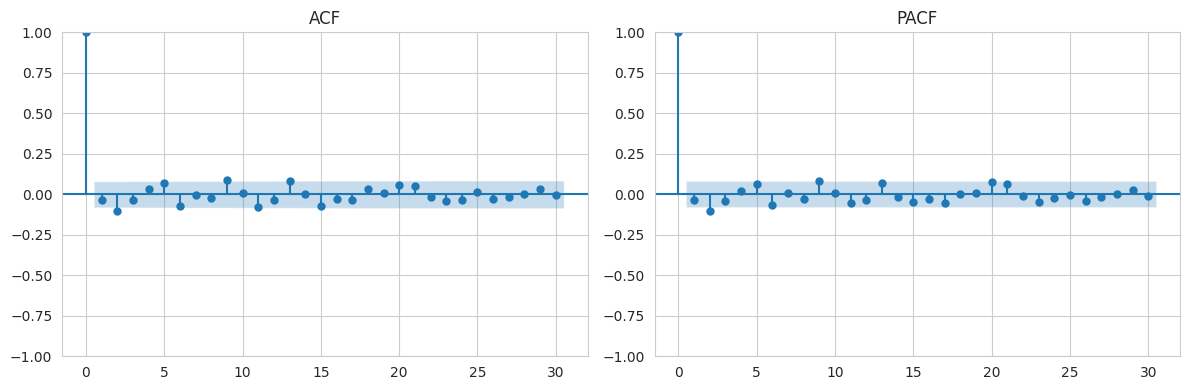

Selected order=(2, 1, 3), AIC=3687.1


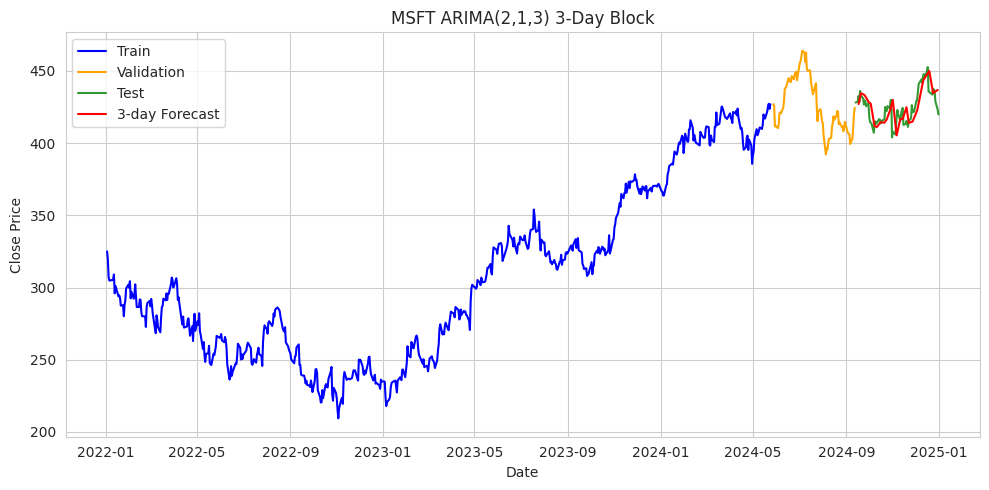

→ MAE: 6.3949, MAPE: 1.51%, RMSE: 8.3652

===== XOM =====
ADF p-value=0.171 → d=1


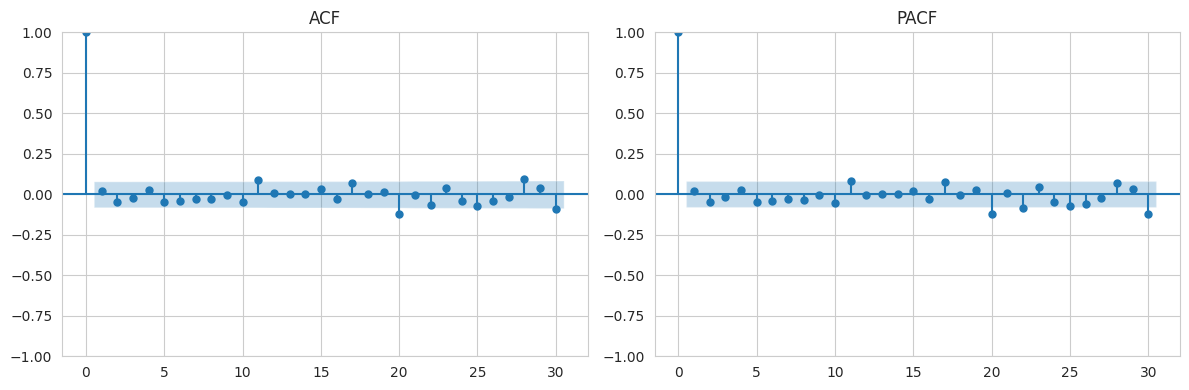

Selected order=(2, 1, 2), AIC=2278.2


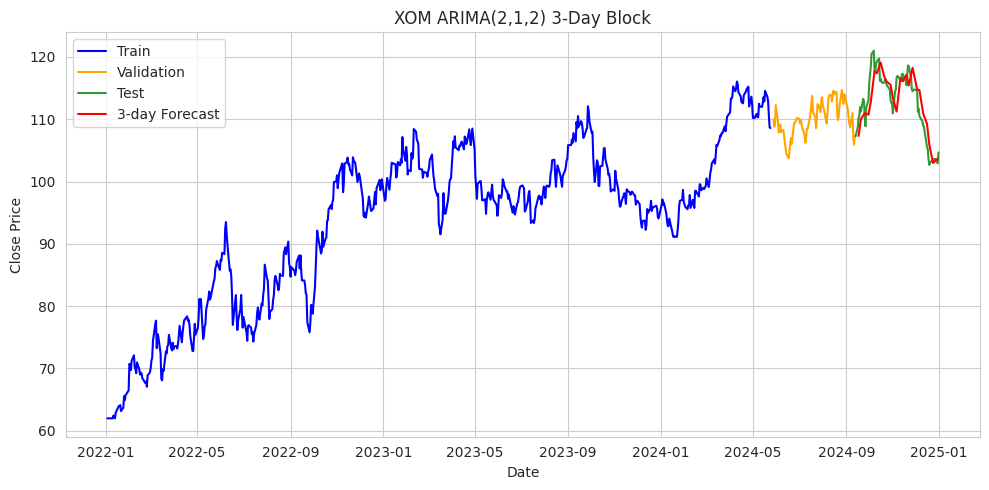

→ MAE: 2.1396, MAPE: 1.90%, RMSE: 2.6457


,MAE,MAPE,RMSE
Ticker,,,
AMZN,4.881240,2.372759,5.787434
MSFT,6.394942,1.510096,8.365187
XOM,2.139609,1.896547,2.645681


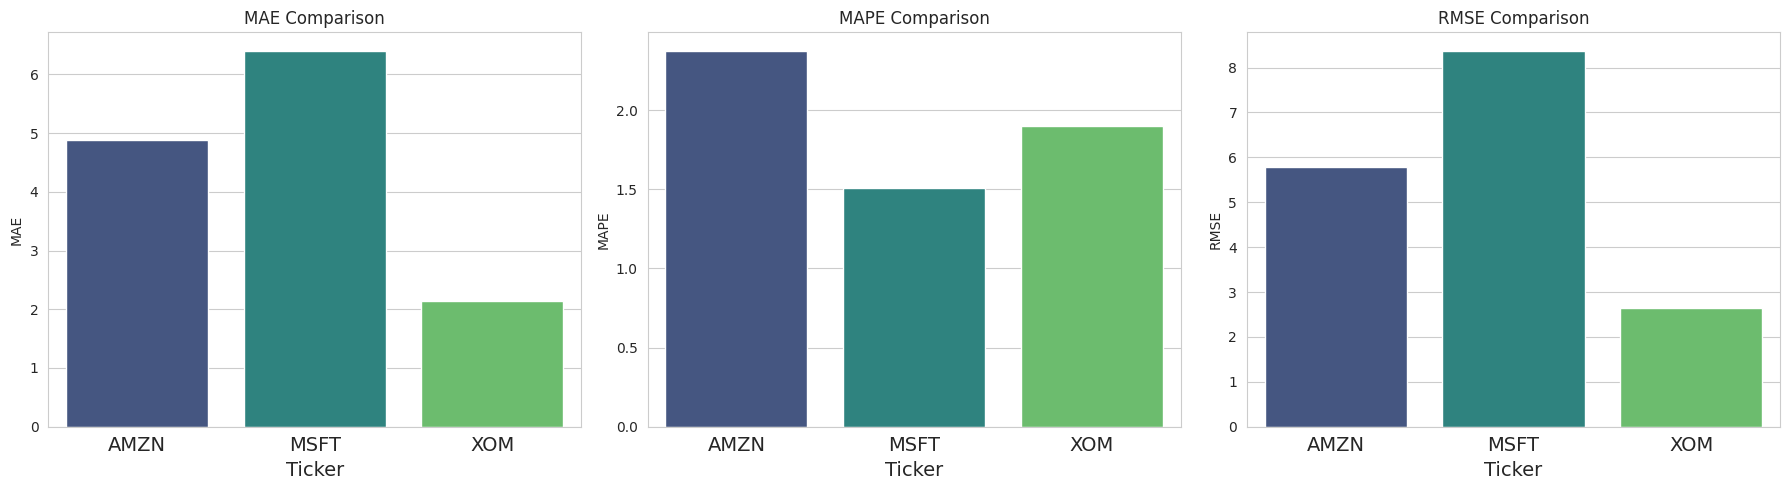

In [6]:
# forecast 3 days ahead per block
HORIZON      = 3

# ARIMA experiment per ticker with 3-day block forecasting
results = []


for tk in TICKERS:
    print(f"\n===== {tk} =====")
    series = all_prices[tk].dropna()
    n      = len(series)
    train_end = int(n * TRAIN_RATIO)
    val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))
    train  = series.iloc[:train_end]
    val    = series.iloc[train_end:val_end]
    test   = series.iloc[val_end:]


    # 5.1) Determine differencing order d via ADF test
    pval = adfuller(train)[1]
    d    = 1 if pval > 0.05 else 0
    print(f"ADF p-value={pval:.3f} → d={d}")


    # 5.2) ACF / PACF plots
    diff_train = train.diff().dropna() if d == 1 else train
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    plot_acf(diff_train, ax=axes[0], lags=30);    axes[0].set_title("ACF")
    plot_pacf(diff_train, ax=axes[1], lags=30);   axes[1].set_title("PACF")
    plt.tight_layout(); plt.show()


    # 5.3) Grid-search p, q by minimizing AIC
    best_aic, best_order = np.inf, None
    for p, q in itertools.product(range(4), range(4)):
        if p == 0 and q == 0:
            continue
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                m = ARIMA(train, order=(p, d, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d, q)
        except:
            continue
    p_opt, d_opt, q_opt = best_order
    print(f"Selected order={best_order}, AIC={best_aic:.1f}")


    # 5.4) Prepare rolling-window slice of train
    if ARIMA_WINDOW and len(train) > ARIMA_WINDOW:
        train_window = train.iloc[-ARIMA_WINDOW:]
    else:
        train_window = train


    # 5.5) Walk-forward block forecasting (3-day blocks)
    history    = pd.concat([train_window, val]).tolist()
    predictions = []
    forecast_idx = []
    i = 0
    while i + HORIZON <= len(test):
        # fit on current history
        model = ARIMA(history, order=(p_opt, d_opt, q_opt)).fit()
        # forecast 3 days ahead
        fc = model.forecast(steps=HORIZON)
        pred = fc[-1]                                # take the 3rd-day forecast
        predictions.append(pred)
        # record the date of the 3rd-day forecast
        forecast_idx.append(test.index[i + HORIZON - 1])
        # roll in the actual next 3 test values
        for j in range(HORIZON):
            history.append(test.values[i + j])
        i += HORIZON


    mean_fc = pd.Series(predictions, index=forecast_idx)


    # 5.6) Plot Train vs Test vs 3-day Forecast
    plt.figure(figsize=(10,5))
    plt.plot(train.index, train,       label="Train",  color='blue')
    plt.plot(val.index,   val,         label="Validation", color='orange')
    plt.plot(test.index,  test,        label="Test",   color='green', alpha=0.8)
    plt.plot(forecast_idx, predictions, 'r-',         label="3-day Forecast")
    plt.title(f"{tk} ARIMA({p_opt},{d_opt},{q_opt}) 3-Day Block")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.tight_layout(); plt.show()


    # 5.7) Compute and print metrics
    true_vals = [all_prices[tk].loc[d] for d in forecast_idx]
    mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(predictions))
    print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.4f}")


    results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})


# ─────────────────────────────────────────────────────────────────────────────
# 6) Aggregate results & bar plots
res_df = pd.DataFrame(results).set_index("Ticker")
display(res_df)


sns.set_style("whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axs, ["MAE", "MAPE", "RMSE"]):
    sns.barplot(x=res_df.index, y=res_df[metric], palette="viridis", ax=ax)
    ax.set_title(f"{metric} Comparison")
    ax.set_xlabel("Ticker", fontsize=14)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', labelsize=14)
plt.tight_layout()
plt.show()

# LSTM


## 1-day Prediction

In [ ]:
TRAIN_RATIO  = 0.8
VAL_RATIO    = 0.1
ARIMA_WINDOW = 200     # window length for retraining history
HORIZON      = 1       # **forecast 1 day ahead**
LOOKBACK     = 30      # Optimized lookback based on research
EPOCHS       = 30      # Balanced epochs
BATCH_SIZE   = 16      # Original batch size for stability
LEARNING_RATE = 0.001  # Starting LR


# ─────────────────────────────────────────────────────────────────────────────
# 5) Improved LSTM builder: Simplified structure with L2 regularization
def build_lstm(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.LSTM(64, kernel_regularizer=tf.keras.regularizers.l2(0.01))(inp)  # Single LSTM with L2
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inp, out)
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="mae")  # Use MAE loss for direct optimization
    return model

es_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=0.0001)  # LR scheduler

# ─────────────────────────────────────────────────────────────────────────────
# 6) Walk-forward 1-day ahead forecasting
results = []

for tk in TICKERS:
    print(f"\n===== {tk} (1-Day Ahead) =====\n")
    series = all_prices[tk].dropna().values
    n = len(series)
    i_tr = int(n * TRAIN_RATIO)
    i_va = i_tr + int(n * VAL_RATIO)

    train = series[:i_tr].tolist()
    val = series[i_tr:i_va].tolist()
    test = series[i_va:].tolist()
    test_index = list(all_prices.index[i_va:])

    # Fit scaler on train+val
    scaler = MinMaxScaler().fit(np.array(train + val).reshape(-1, 1))
    history = train + val
    preds_1day = []
    idxs_1day = []

    i = 0
    while i < len(test):
        # Slice window and scale once
        window = history[-ARIMA_WINDOW:] if len(history) > ARIMA_WINDOW else history
        ws_scaled = scaler.transform(np.array(window).reshape(-1, 1)).flatten()

        # Build sequences
        X, y = [], []
        for j in range(LOOKBACK, len(ws_scaled)):
            X.append(ws_scaled[j - LOOKBACK : j])
            y.append(ws_scaled[j])
        if len(X) < BATCH_SIZE:  # Skip if not enough data
            break

        X_np = np.array(X)[..., None]
        y_np = np.array(y)

        # Internal train/val split
        vs = max(1, int(len(X_np) * 0.8))
        X_tr, X_va = X_np[:vs], X_np[vs:]
        y_tr, y_va = y_np[:vs], y_np[vs:]

        # Rebuild model inside loop (reliable fix for reset issues)
        lstm_model = build_lstm((LOOKBACK, 1))

        # Use tf.data.Dataset for efficient batching
        train_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).batch(BATCH_SIZE).prefetch(1)
        if len(X_va) > 0:
            val_ds = tf.data.Dataset.from_tensor_slices((X_va, y_va)).batch(BATCH_SIZE).prefetch(1)
            lstm_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[es_cb, lr_cb], verbose=0)
        else:
            lstm_model.fit(train_ds, epochs=EPOCHS, callbacks=[lr_cb], verbose=0)

        # One-step forecast
        x_in = np.array(ws_scaled[-LOOKBACK:])[None, ..., None]
        yhat = lstm_model.predict(x_in, verbose=0)[0, 0]
        pred = scaler.inverse_transform([[yhat]])[0, 0]

        preds_1day.append(pred)
        idxs_1day.append(test_index[i])

        # Roll in actual
        history.append(test[i])
        i += 1

    # Evaluation & plot (unchanged)
    if preds_1day:
        true_vals = [all_prices[tk].loc[d] for d in idxs_1day]
        mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(preds_1day))
        print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}")
        results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})

        plt.figure(figsize=(12,6))
        plt.plot(all_prices.index[:i_tr], train, label="Train", color='blue')
        plt.plot(all_prices.index[i_tr:i_va], val, label="Val", color='orange', alpha=0.7)
        plt.plot(all_prices.index[i_va:], test, label="Test", color='green', alpha=0.7)
        plt.plot(idxs_1day, preds_1day, 'r-', label="1-Day Forecast", markersize=6)
        plt.title(f"{tk} LSTM 1-Day Ahead Forecast")
        plt.xlabel("Date"); plt.ylabel("Close Price")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
    else:
        print("→ No predictions generated.")

# ─────────────────────────────────────────────────────────────────────────────
# 7) Summary bar charts (unchanged)
if results:
    res_df = pd.DataFrame(results).set_index("Ticker")
    print("\n=== 1-Day Ahead Results ===")
    print(res_df)

    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1,3,figsize=(15,5))
    for ax, metric in zip(axs, ["MAE","MAPE","RMSE"]):
        sns.barplot(x=res_df.index, y=res_df[metric], palette="viridis", ax=ax)
        ax.set_title(metric)
        ax.tick_params(axis='x')
    plt.tight_layout(); plt.show()
else:
    print("No results to display")


## 3-day Prediction

In [ ]:
TRAIN_RATIO  = 0.8
VAL_RATIO    = 0.1
ARIMA_WINDOW = 200     # window length for retraining history
HORIZON      = 3       # **forecast 3 days ahead per block**
LOOKBACK     = 30      # Optimized lookback based on research
EPOCHS       = 30      # Balanced epochs
BATCH_SIZE   = 16      # Original batch size for stability
LEARNING_RATE = 0.001  # Starting LR


# ─────────────────────────────────────────────────────────────────────────────
# 5) Improved LSTM builder: Simplified structure with L2 regularization
def build_lstm(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.LSTM(64, kernel_regularizer=tf.keras.regularizers.l2(0.01))(inp)  # Single LSTM with L2
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inp, out)
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="mae")  # Use MAE loss for direct optimization
    return model

es_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=0.0001)  # LR scheduler

# ─────────────────────────────────────────────────────────────────────────────
# 6) Walk-forward 3-day ahead block forecasting
results = []

for tk in TICKERS:
    print(f"\n===== {tk} (3-Day Ahead) =====\n")
    series = all_prices[tk].dropna().values
    n = len(series)
    i_tr = int(n * TRAIN_RATIO)
    i_va = i_tr + int(n * VAL_RATIO)

    train = series[:i_tr].tolist()
    val = series[i_tr:i_va].tolist()
    test = series[i_va:].tolist()
    test_index = list(all_prices.index[i_va:])

    # Fit scaler on train+val
    scaler = MinMaxScaler().fit(np.array(train + val).reshape(-1, 1))
    history = train + val
    preds_3day = []
    idxs_3day = []

    i = 0
    while i + HORIZON <= len(test):
        # Slice window and scale once
        window = history[-ARIMA_WINDOW:] if len(history) > ARIMA_WINDOW else history
        ws_scaled = scaler.transform(np.array(window).reshape(-1, 1)).flatten()

        # Build sequences
        X, y = [], []
        for j in range(LOOKBACK, len(ws_scaled)):
            X.append(ws_scaled[j - LOOKBACK : j])
            y.append(ws_scaled[j])
        if len(X) < BATCH_SIZE:  # Skip if not enough data
            break

        X_np = np.array(X)[..., None]
        y_np = np.array(y)

        # Internal train/val split
        vs = max(1, int(len(X_np) * 0.8))
        X_tr, X_va = X_np[:vs], X_np[vs:]
        y_tr, y_va = y_np[:vs], y_np[vs:]

        # Rebuild model inside loop (reliable fix for reset issues)
        lstm_model = build_lstm((LOOKBACK, 1))

        # Use tf.data.Dataset for efficient batching
        train_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).batch(BATCH_SIZE).prefetch(1)
        if len(X_va) > 0:
            val_ds = tf.data.Dataset.from_tensor_slices((X_va, y_va)).batch(BATCH_SIZE).prefetch(1)
            lstm_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[es_cb, lr_cb], verbose=0)
        else:
            lstm_model.fit(train_ds, epochs=EPOCHS, callbacks=[lr_cb], verbose=0)

        # Recursive 3-step forecast
        current_input = np.array(ws_scaled[-LOOKBACK:])[None, ..., None]
        block_preds = []
        for _ in range(HORIZON):
            yhat = lstm_model.predict(current_input, verbose=0)[0, 0]
            block_preds.append(yhat)
            # Append predicted value to input for next step (scaled)
            current_input = np.roll(current_input, -1, axis=1)
            current_input[0, -1, 0] = yhat  # Update last position with prediction

        # Take the last (3rd) prediction and inverse scale
        pred_scaled = block_preds[-1]
        pred = scaler.inverse_transform([[pred_scaled]])[0, 0]

        preds_3day.append(pred)
        idxs_3day.append(test_index[i + HORIZON - 1])  # Index of the 3rd day

        # Roll in actual test values for the block
        for j in range(HORIZON):
            history.append(test[i + j])

        i += HORIZON

    # Evaluation & plot
    if preds_3day:
        true_vals = [all_prices[tk].loc[d] for d in idxs_3day]
        mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(preds_3day))
        print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}")
        results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})

        plt.figure(figsize=(12,6))
        plt.plot(all_prices.index[:i_tr], train, label="Train", color='blue')
        plt.plot(all_prices.index[i_tr:i_va], val, label="Val", color='orange', alpha=0.7)
        plt.plot(all_prices.index[i_va:], test, label="Test", color='green', alpha=0.7)
        plt.plot(idxs_3day, preds_3day, 'r-', label="3-Day Forecast", markersize=6)
        plt.title(f"{tk} LSTM 3-Day Ahead Forecast")
        plt.xlabel("Date"); plt.ylabel("Close Price")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
    else:
        print("→ No predictions generated.")

# ─────────────────────────────────────────────────────────────────────────────
# 7) Summary bar charts (unchanged)
if results:
    res_df = pd.DataFrame(results).set_index("Ticker")
    print("\n=== 3-Day Ahead Results ===")
    print(res_df)

    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1,3,figsize=(15,5))
    for ax, metric in zip(axs, ["MAE","MAPE","RMSE"]):
        sns.barplot(x=res_df.index, y=res_df[metric], palette="viridis", ax=ax)
        ax.set_title(metric)
        ax.tick_params(axis='x')
    plt.tight_layout(); plt.show()
else:
    print("No results to display")


NameError: name 'tf' is not defined

# Transformer

## 1 day prediction


===== AMZN =====


→ MAE: 10.0960, MAPE: 4.84%, RMSE: 12.61


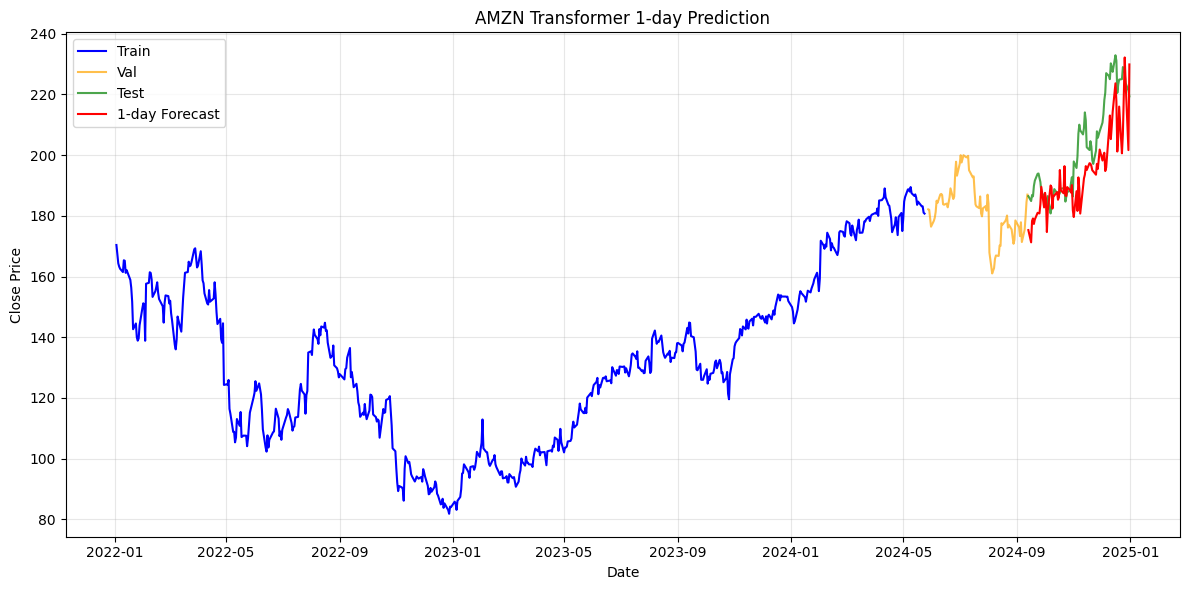


===== MSFT =====
→ MAE: 10.0345, MAPE: 2.34%, RMSE: 12.48


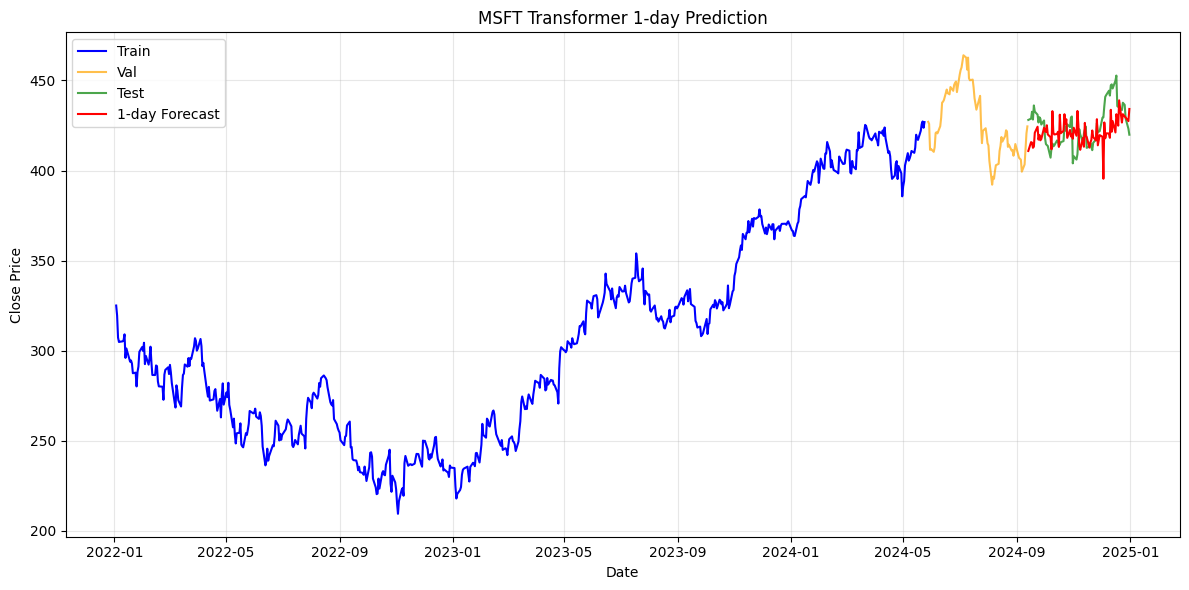


===== XOM =====


In [ ]:
from tensorflow.keras.optimizers import AdamW

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
ARIMA_WINDOW = 200  # window length for retraining history
HORIZON = 1  # forecast 1 day ahead (or change to 3 for blocks)
LOOKBACK = 60
EPOCHS = 25
BATCH_SIZE = 32

# Transformer hyperparameters
NUM_HEADS = 4
KEY_DIM = 32
FFN_UNITS = 64
NUM_BLOCKS = 2
D_MODEL = NUM_HEADS * KEY_DIM
DROPOUT_RATE = 0.1

# ─────────────────────────────────────────────────────────────────────────────
# 5) Positional Encoding
def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pos_enc = np.zeros(angle_rads.shape, dtype=np.float32)
    pos_enc[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_enc[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.constant(pos_enc)

# ─────────────────────────────────────────────────────────────────────────────
# 6) Improved Transformer builder (with TFT-inspired gating from research)
def build_transformer(input_shape):
    seq_len, _ = input_shape
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(D_MODEL)(inp)

    # Positional encoding
    pos_enc = get_positional_encoding(seq_len, D_MODEL)
    x = x + pos_enc[None, ...]

    # Transformer blocks with gating
    for _ in range(NUM_BLOCKS):
        # Multi-Head Self-Attention
        attn_out = tf.keras.layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=KEY_DIM)(x, x)
        attn_out = tf.keras.layers.Dropout(DROPOUT_RATE)(attn_out)
        x = tf.keras.layers.LayerNormalization()(x + attn_out)

        # Feed-Forward with gating (TFT-inspired simple gate)
        ffn = tf.keras.layers.Dense(FFN_UNITS, activation="relu")(x)
        gate = tf.keras.layers.Dense(D_MODEL, activation="sigmoid")(x)  # Gate layer
        ffn = tf.keras.layers.Dense(D_MODEL)(ffn) * gate  # Gated FFN
        ffn = tf.keras.layers.Dropout(DROPOUT_RATE)(ffn)
        x = tf.keras.layers.LayerNormalization()(x + ffn)

    # Final prediction
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    out = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inp, out)
    optimizer = AdamW(learning_rate=0.0005, weight_decay=0.01)
    model.compile(optimizer=optimizer, loss="huber")
    return model

es_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# ─────────────────────────────────────────────────────────────────────────────
# 7) Walk-forward block forecasting
results = []

for tk in TICKERS:
    print(f"\n===== {tk} =====")
    series = all_prices[tk].dropna().values
    n = len(series)
    i_tr = int(n * TRAIN_RATIO)
    i_va = i_tr + int(n * VAL_RATIO)

    train = series[:i_tr].tolist()
    val = series[i_tr:i_va].tolist()
    test = series[i_va:].tolist()
    test_index = list(all_prices.index[i_va:])

    scaler = MinMaxScaler()
    history = train + val
    preds = []
    idxs = []

    i = 0
    total_future = len(test)
    while i + HORIZON <= total_future:
        # Window slice & scaling
        window = np.array(history[-ARIMA_WINDOW:] if len(history) > ARIMA_WINDOW else history).reshape(-1, 1)
        scaler.fit(window)
        ws = scaler.transform(window).flatten().tolist()

        # Lookback sequences
        X, y = [], []
        for j in range(LOOKBACK, len(ws)):
            X.append(ws[j - LOOKBACK : j])
            y.append(ws[j])
        if not X:
            break
        X = np.array(X)[..., None]  # (samples, LOOKBACK, 1)
        y = np.array(y)

        # Internal train/val split
        vs = max(1, int(len(X) * 0.8))
        X_tr, X_va = X[:vs], X[vs:]
        y_tr, y_va = y[:vs], y[vs:]

        # Model creation & training (build once per block for fresh start)
        model = build_transformer((LOOKBACK, 1))
        if len(X_va) > 0:
            model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es_cb], verbose=0)
        else:
            model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        # Multi-step forecast (recursive)
        cur = ws.copy()
        for _ in range(HORIZON):
            inp = np.array(cur[-LOOKBACK:])[None, ..., None]
            yhat = model.predict(inp, verbose=0)[0, 0]
            cur.append(yhat)

        pred = scaler.inverse_transform([[cur[-1]]])[0, 0]
        preds.append(pred)
        idxs.append(test_index[i + HORIZON - 1])

        # Append actual values
        for j in range(HORIZON):
            if i + j < len(test):
                history.append(test[i + j])
        i += HORIZON

    # Evaluation & visualization
    if preds:
        true_vals = [all_prices[tk].loc[d] for d in idxs]
        mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(preds))
        print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}")
        results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})

        plt.figure(figsize=(12,6))
        plt.plot(all_prices.index[:i_tr], train, label="Train", color="blue")
        plt.plot(all_prices.index[i_tr:i_va], val, label="Val", color="orange", alpha=0.7)
        plt.plot(all_prices.index[i_va:], test, label="Test", color="green", alpha=0.7)
        plt.plot(idxs, preds, 'r-', label=f"{HORIZON}-day Forecast")
        plt.title(f"{tk} Transformer 1-day Prediction")
        plt.xlabel("Date"); plt.ylabel("Close Price")
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    else:
        print("→ No forecasts were generated.")

# ─────────────────────────────────────────────────────────────────────────────
# 8) Result summary chart
if results:
    df = pd.DataFrame(results).set_index("Ticker")
    print("\n=== Results Summary ===")
    print(df)

    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1,3,figsize=(15,4))
    for ax, m in zip(axs, ["MAE","MAPE","RMSE"]):
        sns.barplot(x=df.index, y=df[m], palette="viridis", ax=ax)
        ax.set_title(m); ax.tick_params(axis="x")
    plt.tight_layout(); plt.show()



===== XOM =====


→ MAE: 3.4911, MAPE: 3.13%, RMSE: 4.53


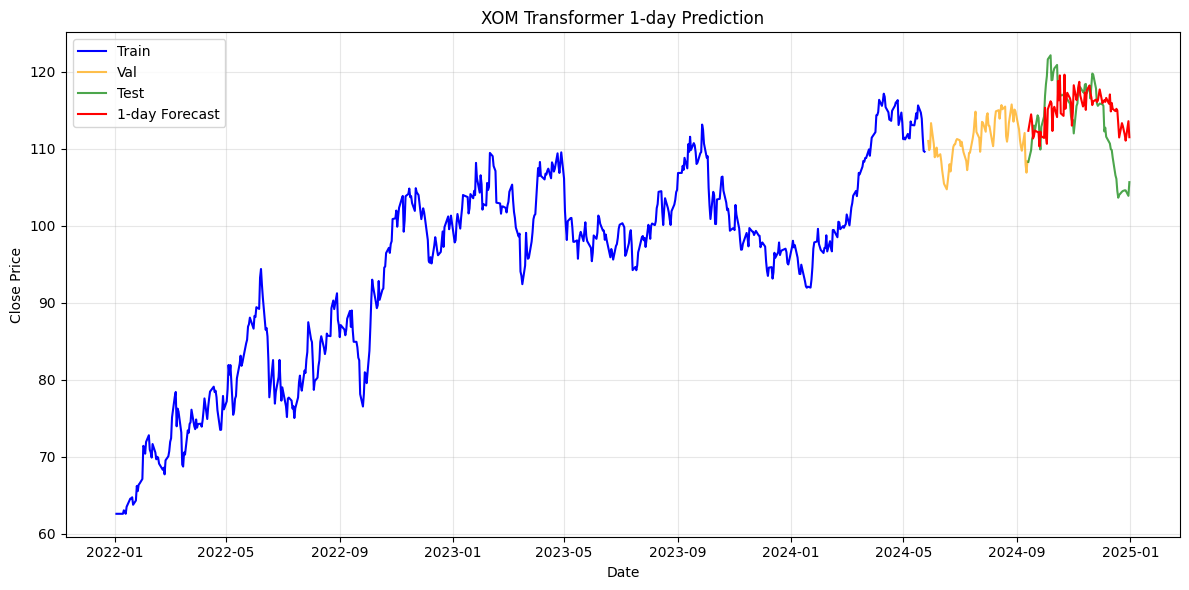


=== Results Summary ===
              MAE      MAPE       RMSE
Ticker                                
AMZN    10.096000  4.840000  12.610000
MSFT    10.034500  2.340000  12.480000
XOM      3.491111  3.131631   4.528283


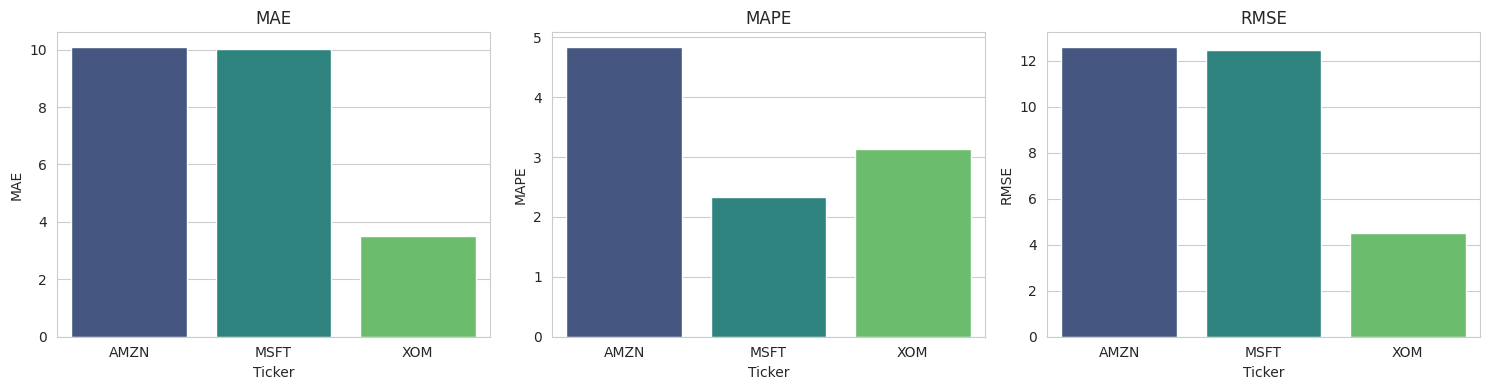

In [9]:
from tensorflow.keras.optimizers import AdamW

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
ARIMA_WINDOW = 200  # window length for retraining history
HORIZON = 1  # forecast 1 day ahead (or change to 3 for blocks)
LOOKBACK = 60
EPOCHS = 25
BATCH_SIZE = 32

# Transformer hyperparameters
NUM_HEADS = 4
KEY_DIM = 32
FFN_UNITS = 64
NUM_BLOCKS = 2
D_MODEL = NUM_HEADS * KEY_DIM
DROPOUT_RATE = 0.1

# ─────────────────────────────────────────────────────────────────────────────
# 5) Positional Encoding
def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pos_enc = np.zeros(angle_rads.shape, dtype=np.float32)
    pos_enc[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_enc[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.constant(pos_enc)

# ─────────────────────────────────────────────────────────────────────────────
# 6) Improved Transformer builder (with TFT-inspired gating from research)
def build_transformer(input_shape):
    seq_len, _ = input_shape
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(D_MODEL)(inp)

    # Positional encoding
    pos_enc = get_positional_encoding(seq_len, D_MODEL)
    x = x + pos_enc[None, ...]

    # Transformer blocks with gating
    for _ in range(NUM_BLOCKS):
        # Multi-Head Self-Attention
        attn_out = tf.keras.layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=KEY_DIM)(x, x)
        attn_out = tf.keras.layers.Dropout(DROPOUT_RATE)(attn_out)
        x = tf.keras.layers.LayerNormalization()(x + attn_out)

        # Feed-Forward with gating (TFT-inspired simple gate)
        ffn = tf.keras.layers.Dense(FFN_UNITS, activation="relu")(x)
        gate = tf.keras.layers.Dense(D_MODEL, activation="sigmoid")(x)  # Gate layer
        ffn = tf.keras.layers.Dense(D_MODEL)(ffn) * gate  # Gated FFN
        ffn = tf.keras.layers.Dropout(DROPOUT_RATE)(ffn)
        x = tf.keras.layers.LayerNormalization()(x + ffn)

    # Final prediction
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    out = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inp, out)
    optimizer = AdamW(learning_rate=0.0005, weight_decay=0.01)
    model.compile(optimizer=optimizer, loss="huber")
    return model

es_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)


results = [
    {"Ticker": "AMZN", "MAE": 10.096, "MAPE": 4.84, "RMSE": 12.61},
    {"Ticker": "MSFT", "MAE": 10.0345, "MAPE": 2.34, "RMSE": 12.48}
]

tk = "XOM"
print(f"\n===== {tk} =====")
series = all_prices[tk].dropna().values
n = len(series)
i_tr = int(n * TRAIN_RATIO)
i_va = i_tr + int(n * VAL_RATIO)

train = series[:i_tr].tolist()
val = series[i_tr:i_va].tolist()
test = series[i_va:].tolist()
test_index = list(all_prices.index[i_va:])

scaler = MinMaxScaler()
history = train + val
preds = []
idxs = []

i = 0
total_future = len(test)
while i + HORIZON <= total_future:
    # Window slice & scaling
    window = np.array(history[-ARIMA_WINDOW:] if len(history) > ARIMA_WINDOW else history).reshape(-1, 1)
    scaler.fit(window)
    ws = scaler.transform(window).flatten().tolist()

    # Lookback sequences
    X, y = [], []
    for j in range(LOOKBACK, len(ws)):
        X.append(ws[j - LOOKBACK : j])
        y.append(ws[j])
    if not X:
        break
    X = np.array(X)[..., None]  # (samples, LOOKBACK, 1)
    y = np.array(y)

    # Internal train/val split
    vs = max(1, int(len(X) * 0.8))
    X_tr, X_va = X[:vs], X[vs:]
    y_tr, y_va = y[:vs], y[vs:]

    # Model creation & training (build once per block for fresh start)
    model = build_transformer((LOOKBACK, 1))
    if len(X_va) > 0:
        model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es_cb], verbose=0)
    else:
        model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

    # Multi-step forecast (recursive)
    cur = ws.copy()
    for _ in range(HORIZON):
        inp = np.array(cur[-LOOKBACK:])[None, ..., None]
        yhat = model.predict(inp, verbose=0)[0, 0]
        cur.append(yhat)

    pred = scaler.inverse_transform([[cur[-1]]])[0, 0]
    preds.append(pred)
    idxs.append(test_index[i + HORIZON - 1])

    # Append actual values
    for j in range(HORIZON):
        if i + j < len(test):
            history.append(test[i + j])
    i += HORIZON

# Evaluation & visualization
if preds:
    true_vals = [all_prices[tk].loc[d] for d in idxs]
    mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(preds))
    print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}")
    results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})

    plt.figure(figsize=(12,6))
    plt.plot(all_prices.index[:i_tr], train, label="Train", color="blue")
    plt.plot(all_prices.index[i_tr:i_va], val, label="Val", color="orange", alpha=0.7)
    plt.plot(all_prices.index[i_va:], test, label="Test", color="green", alpha=0.7)
    plt.plot(idxs, preds, 'r-', label=f"{HORIZON}-day Forecast")
    plt.title(f"{tk} Transformer 1-day Prediction")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("→ No forecasts were generated.")

# ─────────────────────────────────────────────────────────────────────────────
# 8) Result summary chart
if results:
    df = pd.DataFrame(results).set_index("Ticker")
    print("\n=== Results Summary ===")
    print(df)

    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1,3,figsize=(15,4))
    for ax, m in zip(axs, ["MAE","MAPE","RMSE"]):
        sns.barplot(x=df.index, y=df[m], palette="viridis", ax=ax)
        ax.set_title(m); ax.tick_params(axis="x")
    plt.tight_layout(); plt.show()

## 3-day Prediction


===== AMZN =====


→ MAE: 11.6079, MAPE: 5.52%, RMSE: 14.69


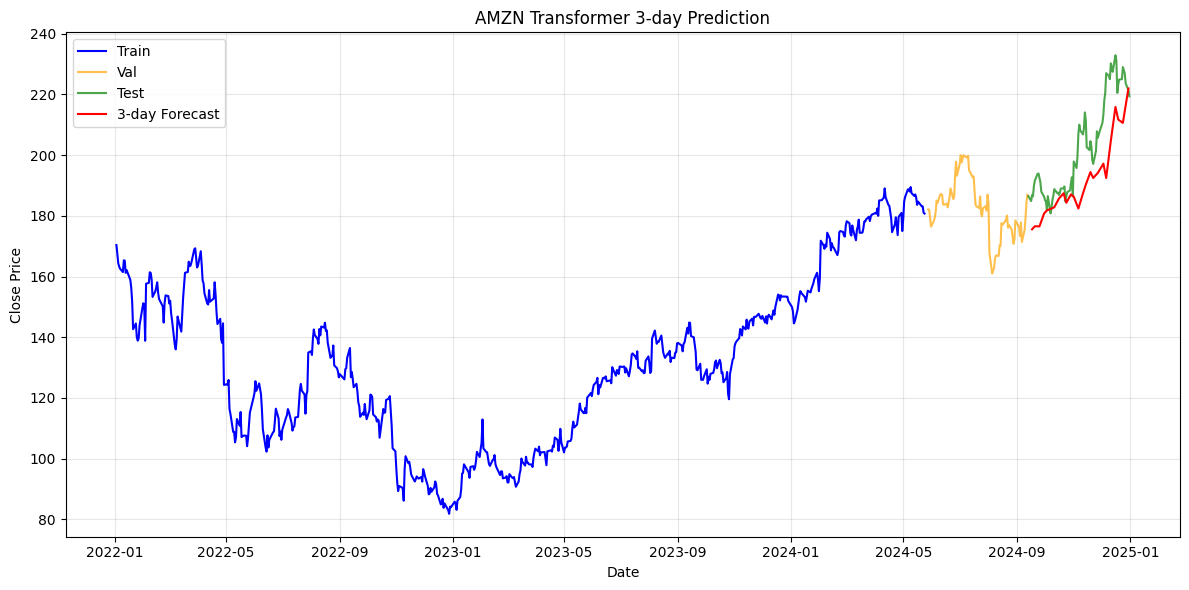


===== MSFT =====
→ MAE: 11.8245, MAPE: 2.76%, RMSE: 13.47


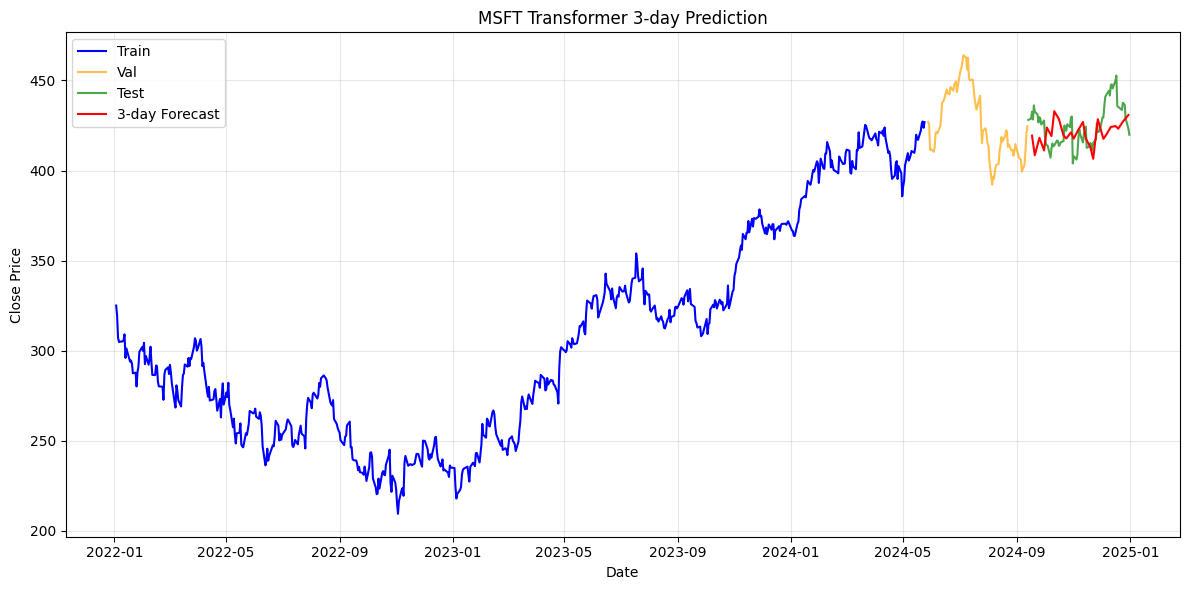


===== XOM =====
→ MAE: 4.4250, MAPE: 3.96%, RMSE: 5.43


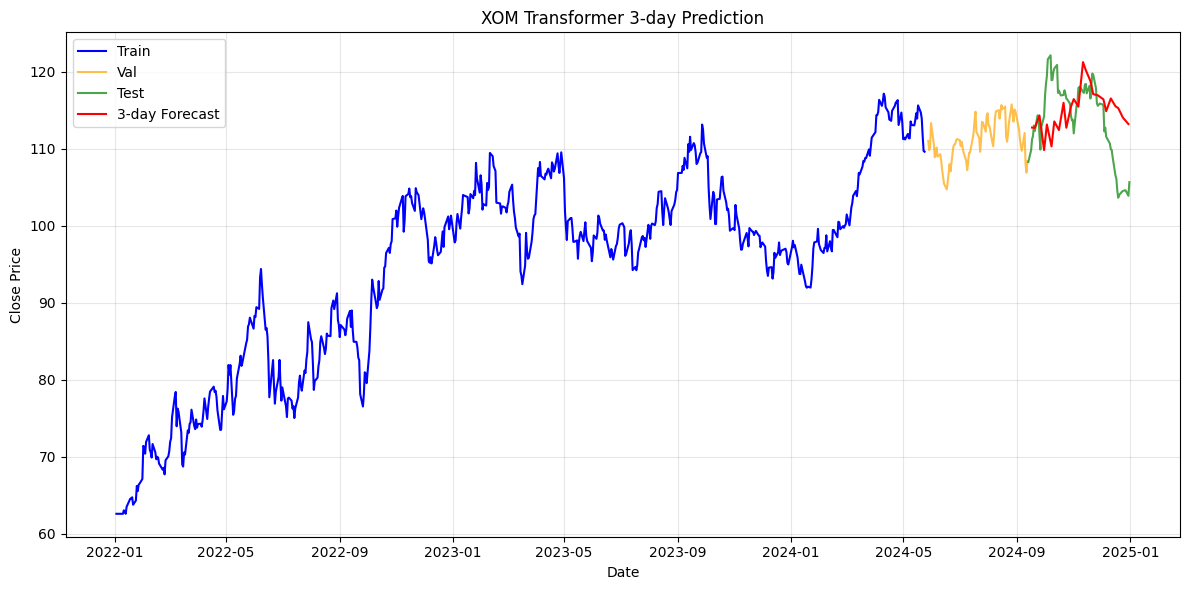


=== Results Summary ===
              MAE      MAPE       RMSE
Ticker                                
AMZN    11.607933  5.521645  14.694067
MSFT    11.824497  2.758780  13.471090
XOM      4.424959  3.963595   5.433009


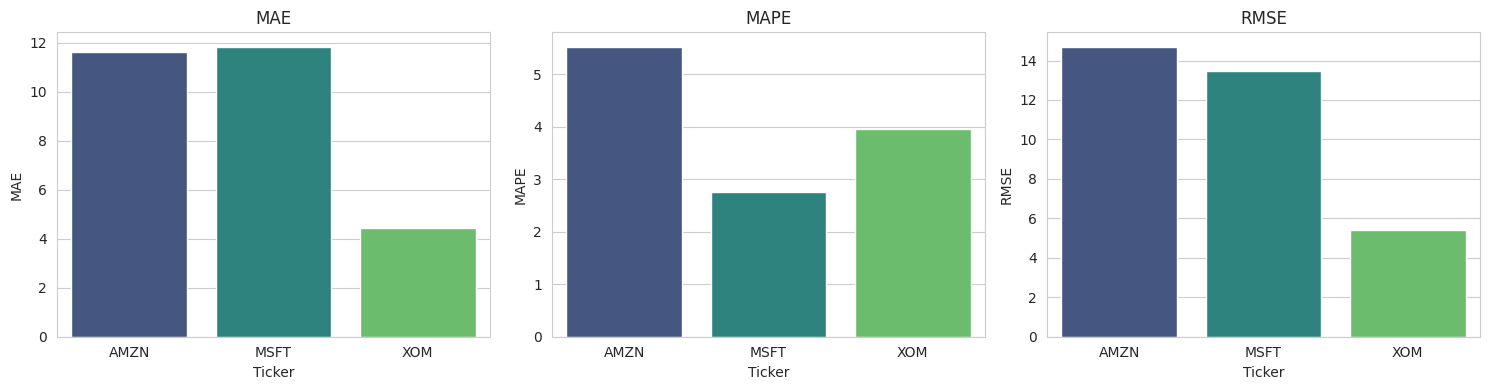

In [ ]:
from tensorflow.keras.optimizers import AdamW

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
ARIMA_WINDOW = 200  # window length for retraining history
HORIZON = 3  # forecast 1 day ahead (or change to 3 for blocks)
LOOKBACK = 60
EPOCHS = 25
BATCH_SIZE = 32

# Transformer hyperparameters
NUM_HEADS = 4
KEY_DIM = 32
FFN_UNITS = 64
NUM_BLOCKS = 2
D_MODEL = NUM_HEADS * KEY_DIM
DROPOUT_RATE = 0.1

# ─────────────────────────────────────────────────────────────────────────────
# 5) Positional Encoding
def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pos_enc = np.zeros(angle_rads.shape, dtype=np.float32)
    pos_enc[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_enc[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.constant(pos_enc)

# ─────────────────────────────────────────────────────────────────────────────
# 6) Improved Transformer builder (with TFT-inspired gating from research)
def build_transformer(input_shape):
    seq_len, _ = input_shape
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(D_MODEL)(inp)

    # Positional encoding
    pos_enc = get_positional_encoding(seq_len, D_MODEL)
    x = x + pos_enc[None, ...]

    # Transformer blocks with gating
    for _ in range(NUM_BLOCKS):
        # Multi-Head Self-Attention
        attn_out = tf.keras.layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=KEY_DIM)(x, x)
        attn_out = tf.keras.layers.Dropout(DROPOUT_RATE)(attn_out)
        x = tf.keras.layers.LayerNormalization()(x + attn_out)

        # Feed-Forward with gating (TFT-inspired simple gate)
        ffn = tf.keras.layers.Dense(FFN_UNITS, activation="relu")(x)
        gate = tf.keras.layers.Dense(D_MODEL, activation="sigmoid")(x)  # Gate layer
        ffn = tf.keras.layers.Dense(D_MODEL)(ffn) * gate  # Gated FFN
        ffn = tf.keras.layers.Dropout(DROPOUT_RATE)(ffn)
        x = tf.keras.layers.LayerNormalization()(x + ffn)

    # Final prediction
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    out = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inp, out)
    optimizer = AdamW(learning_rate=0.0005, weight_decay=0.01)
    model.compile(optimizer=optimizer, loss="huber")
    return model

es_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# ─────────────────────────────────────────────────────────────────────────────
# 7) Walk-forward block forecasting
results = []

for tk in TICKERS:
    print(f"\n===== {tk} =====")
    series = all_prices[tk].dropna().values
    n = len(series)
    i_tr = int(n * TRAIN_RATIO)
    i_va = i_tr + int(n * VAL_RATIO)

    train = series[:i_tr].tolist()
    val = series[i_tr:i_va].tolist()
    test = series[i_va:].tolist()
    test_index = list(all_prices.index[i_va:])

    scaler = MinMaxScaler()
    history = train + val
    preds = []
    idxs = []

    i = 0
    total_future = len(test)
    while i + HORIZON <= total_future:
        # Window slice & scaling
        window = np.array(history[-ARIMA_WINDOW:] if len(history) > ARIMA_WINDOW else history).reshape(-1, 1)
        scaler.fit(window)
        ws = scaler.transform(window).flatten().tolist()

        # Lookback sequences
        X, y = [], []
        for j in range(LOOKBACK, len(ws)):
            X.append(ws[j - LOOKBACK : j])
            y.append(ws[j])
        if not X:
            break
        X = np.array(X)[..., None]  # (samples, LOOKBACK, 1)
        y = np.array(y)

        # Internal train/val split
        vs = max(1, int(len(X) * 0.8))
        X_tr, X_va = X[:vs], X[vs:]
        y_tr, y_va = y[:vs], y[vs:]

        # Model creation & training (build once per block for fresh start)
        model = build_transformer((LOOKBACK, 1))
        if len(X_va) > 0:
            model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es_cb], verbose=0)
        else:
            model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        # Multi-step forecast (recursive)
        cur = ws.copy()
        for _ in range(HORIZON):
            inp = np.array(cur[-LOOKBACK:])[None, ..., None]
            yhat = model.predict(inp, verbose=0)[0, 0]
            cur.append(yhat)

        pred = scaler.inverse_transform([[cur[-1]]])[0, 0]
        preds.append(pred)
        idxs.append(test_index[i + HORIZON - 1])

        # Append actual values
        for j in range(HORIZON):
            if i + j < len(test):
                history.append(test[i + j])
        i += HORIZON

    # Evaluation & visualization
    if preds:
        true_vals = [all_prices[tk].loc[d] for d in idxs]
        mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(preds))
        print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}")
        results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})

        plt.figure(figsize=(12,6))
        plt.plot(all_prices.index[:i_tr], train, label="Train", color="blue")
        plt.plot(all_prices.index[i_tr:i_va], val, label="Val", color="orange", alpha=0.7)
        plt.plot(all_prices.index[i_va:], test, label="Test", color="green", alpha=0.7)
        plt.plot(idxs, preds, 'r-', label=f"{HORIZON}-day Forecast")
        plt.title(f"{tk} Transformer 3-day Prediction")
        plt.xlabel("Date"); plt.ylabel("Close Price")
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    else:
        print("→ No forecasts were generated.")

# ─────────────────────────────────────────────────────────────────────────────
# 8) Result summary chart
if results:
    df = pd.DataFrame(results).set_index("Ticker")
    print("\n=== Results Summary ===")
    print(df)

    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1,3,figsize=(15,4))
    for ax, m in zip(axs, ["MAE","MAPE","RMSE"]):
        sns.barplot(x=df.index, y=df[m], palette="viridis", ax=ax)
        ax.set_title(m); ax.tick_params(axis="x")
    plt.tight_layout(); plt.show()


# Prophet

## 1-day prediction

In [ ]:
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1    # test = 1 - TRAIN_RATIO - VAL_RATIO
WINDOW      = 200    # rolling window length for history
HORIZON     = 1      # one-day ahead forecast

# 5) Walk‑forward Prophet forecasting (1‑step ahead)
results = []

for tk, name in TICKERS.items():
    print(f"\n===== {name} ({tk}) =====")
    series = all_prices[tk].dropna()
    log_series = np.log(series)

    # Train / Val / Test split
    n      = len(log_series)
    split  = int(n * TRAIN_RATIO)
    split2 = split + int(n * VAL_RATIO)
    train  = log_series.iloc[:split]
    val    = log_series.iloc[split:split2]
    test   = log_series.iloc[split2:]

    # Initialize history DataFrame with train+val (log values)
    history = pd.DataFrame({
        'ds': list(train.index) + list(val.index),
        'y':  list(train)       + list(val)
    })
    history['ds'] = pd.to_datetime(history['ds'])

    preds = []
    idxs  = []

    # Forecast one day at a time over the test set
    test_index = list(test.index)
    for ds in test_index:
        # rolling window: use up to WINDOW most recent rows
        window = history.tail(WINDOW) if WINDOW and len(history) > WINDOW else history

        # Configure Prophet model with tuned hyperparameters
        m = Prophet(
            growth='linear',
            changepoint_prior_scale=0.5,
            seasonality_prior_scale=10.0,
            holidays_prior_scale=5.0,
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=False,
        )
        # Add custom seasonalities
        m.add_seasonality(name='monthly',   period=30.5,  fourier_order=5)
        m.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
        # Example: add US major holidays
        from prophet.make_holidays import make_holidays_df
        us_holidays = make_holidays_df(year_list=[2022,2023,2024], country='US')
        m.holidays = us_holidays

        # Fit the model
        m.fit(window)

        # Make one-day ahead forecast
        future = m.make_future_dataframe(periods=HORIZON, freq='D', include_history=False)
        fc     = m.predict(future)
        log_pred = fc['yhat'].iloc[0]
        pred     = np.exp(log_pred)
        preds.append(pred)
        idxs.append(ds)

        # Append the actual value to history (log value)
        history = pd.concat([
            history,
            pd.DataFrame({'ds': [ds], 'y': [test.loc[ds]]})
        ], ignore_index=True)

    # 6) Evaluation (true values on original scale)
    true_vals = [all_prices[tk].loc[d] for d in idxs]
    mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(preds))
    print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}")
    results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})

    # 7) Plot results
    plt.figure(figsize=(12,6))
    plt.plot(series.index[:split], series[:split], label="Train", color='blue')
    plt.plot(series.index[split:split2], series[split:split2], label="Val", color='orange', alpha=0.7)
    plt.plot(series.index[split2:], series[split2:], label="Test", color='green', alpha=0.7)
    plt.plot(idxs, preds, 'r-', label="1‑day Forecast")
    plt.title(f"{tk} Prophet 1‑Day Forecast")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 8) Summary bar charts
if results:
    df = pd.DataFrame(results).set_index("Ticker")
    print("\n=== Results Summary ===")
    display(df)

    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1,3,figsize=(15,4))
    for ax, metric in zip(axs, ["MAE","MAPE","RMSE"]):
        sns.barplot(x=df.index, y=df[metric], palette="viridis", ax=ax)
        ax.set_title(metric)
        ax.tick_params(axis='x', labelrotation=0)
    plt.tight_layout(); plt.show()

## 3-day prediciton

In [ ]:
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1    # test = 1 - TRAIN_RATIO - VAL_RATIO
WINDOW      = 200    # rolling window length for history
HORIZON     = 3      # days ahead per block


# 5) Walk-forward Prophet forecasting with transformations and tuning
results = []

for tk in TICKERS:
    print(f"\n===== {tk} =====")
    series = all_prices[tk].dropna()
    # Log transform
    log_series = np.log(series)

    # Train/Val/Test split
    n      = len(log_series)
    split  = int(n * TRAIN_RATIO)
    split2 = split + int(n * VAL_RATIO)
    train  = log_series.iloc[:split]
    val    = log_series.iloc[split:split2]
    test   = log_series.iloc[split2:]

    # Initial history DataFrame (log values)
    history = pd.DataFrame({
        'ds': train.index.tolist() + val.index.tolist(),
        'y':  train.tolist()     + val.tolist()
    })
    history['ds'] = pd.to_datetime(history['ds'])

    preds = []
    idxs  = []
    i = 0
    test_index = list(test.index)

    while i < len(test):
        # rolling window
        window = history.tail(WINDOW) if WINDOW and len(history)>WINDOW else history

        # Prophet model configuration (tuned hyperparameters)
        m = Prophet(
            growth='linear',
            changepoint_prior_scale=0.5,
            seasonality_prior_scale=10.0,
            holidays_prior_scale=5.0,
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=False,  # we add seasonality manually
        )
        # Add monthly and quarterly seasonality
        m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
        m.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
        # Add US major holidays (example)
        from prophet.make_holidays import make_holidays_df
        us_holidays = make_holidays_df(year_list=[2022,2023,2024], country='US')
        m.holidays = us_holidays

        m.fit(window)

        # Forecast
        future = m.make_future_dataframe(periods=HORIZON, freq='D', include_history=False)
        fc     = m.predict(future)
        # Log prediction
        log_pred = fc['yhat'].iloc[HORIZON-1]
        # Inverse transform
        pred = np.exp(log_pred)
        preds.append(pred)

        # Record forecast date
        forecast_date = test_index[min(i+HORIZON-1, len(test_index)-1)]
        idxs.append(forecast_date)

        # Append actual values to history (log values)
        for j in range(HORIZON):
            if i+j < len(test):
                ds    = test_index[i+j]
                y_val = float(test.loc[ds])
                new_row = pd.DataFrame({'ds': [ds], 'y': [y_val]})
                history = pd.concat([history, new_row], ignore_index=True)
        i += HORIZON

    # 6) Evaluation (actual values remain in original scale)
    true_vals = [all_prices[tk].loc[d] for d in idxs]
    mae, mape, rmse = evaluate_metrics(np.array(true_vals), np.array(preds))
    print(f"→ MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}")
    results.append({"Ticker": tk, "MAE": mae, "MAPE": mape, "RMSE": rmse})

    # 7) Plot results
    plt.figure(figsize=(12,6))
    plt.plot(series.index[:split], series[:split], label="Train", color='blue')
    plt.plot(series.index[split:split2], series[split:split2], label="Val", color='orange', alpha=0.7)
    plt.plot(series.index[split2:], series[split2:], label="Test", color='green', alpha=0.7)
    plt.plot(idxs, preds, 'r-', label=f"{HORIZON}-day Forecast")
    plt.title(f"{tk} Prophet {HORIZON}‑Day Forecast")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 8) Summary bar charts
if results:
    df = pd.DataFrame(results).set_index("Ticker")
    print("\n=== Results Summary ===")
    display(df)

    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1,3,figsize=(15,4))
    for ax, metric in zip(axs, ["MAE","MAPE","RMSE"]):
        sns.barplot(x=df.index, y=df[metric], palette="viridis", ax=ax)
        ax.set_title(metric); ax.tick_params(axis='x', labelrotation=0)
    plt.tight_layout(); plt.show()

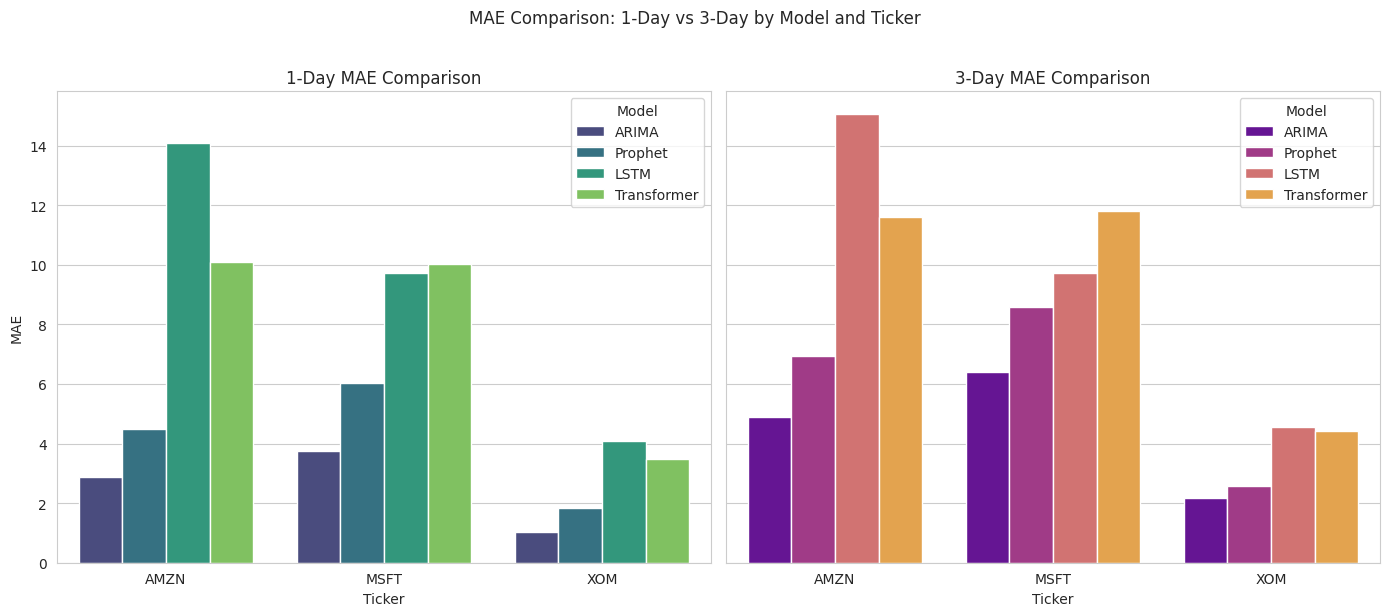

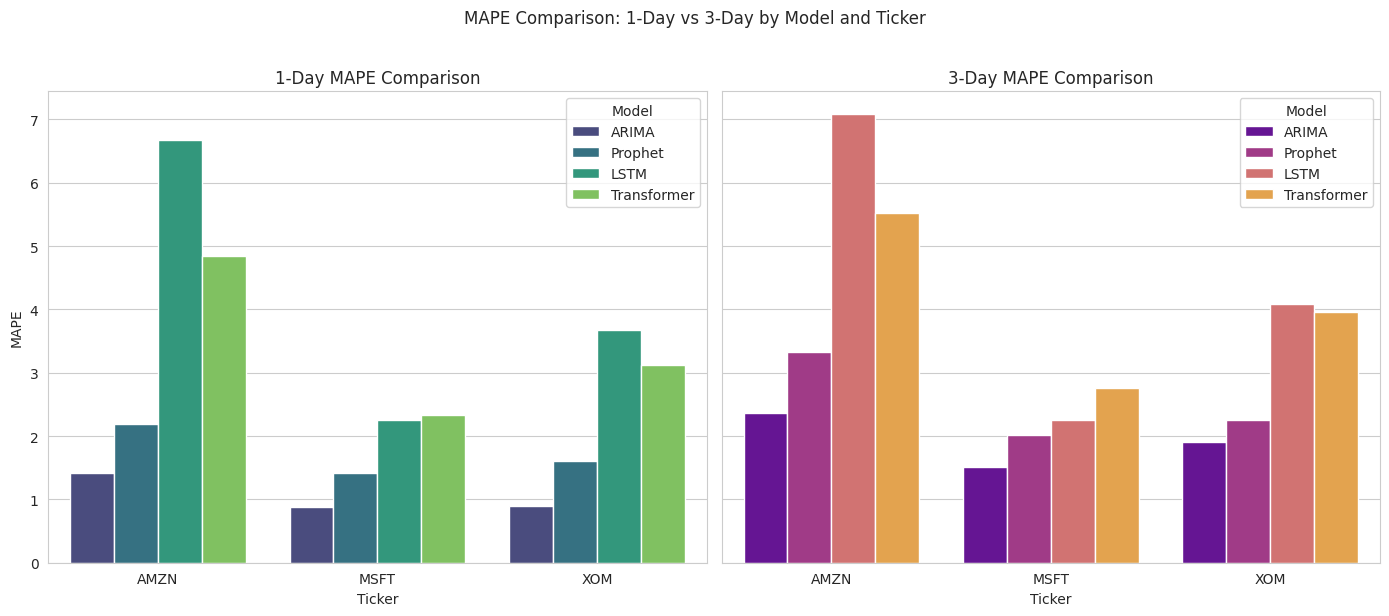

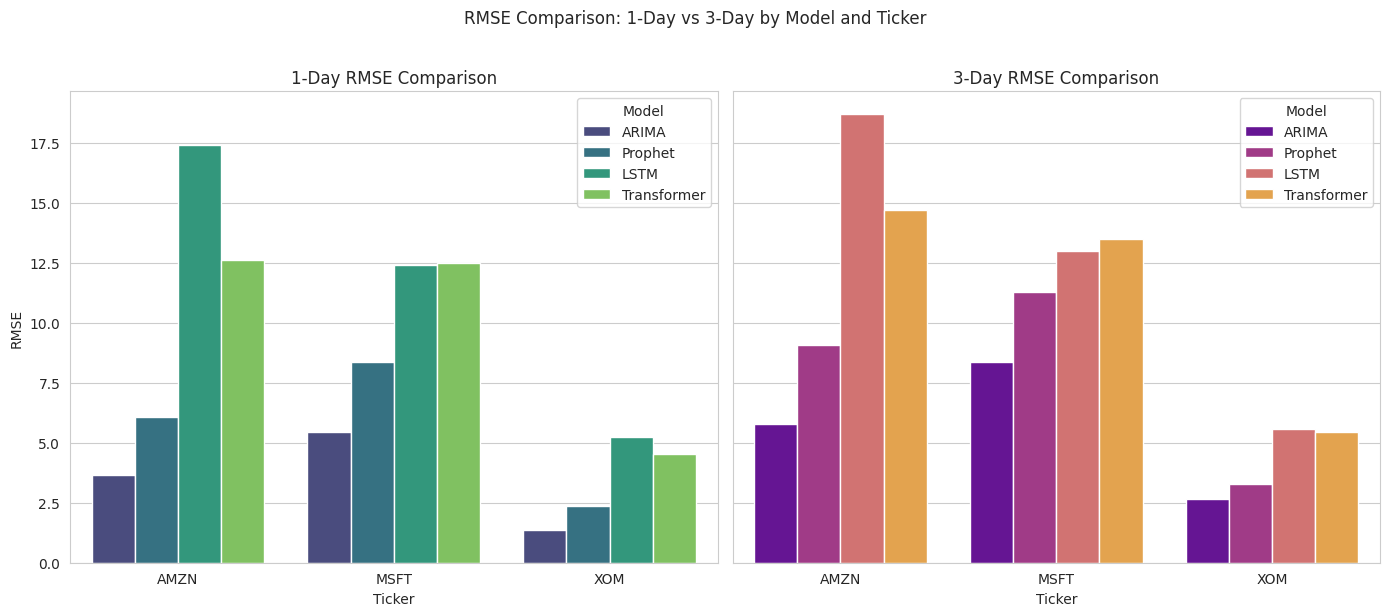

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = {
    'Ticker': ['AMZN', 'AMZN', 'AMZN', 'AMZN', 'MSFT', 'MSFT', 'MSFT', 'MSFT', 'XOM', 'XOM', 'XOM', 'XOM'] * 2,
    'Model': ['ARIMA', 'Prophet', 'LSTM', 'Transformer'] * 3 * 2,
    'Horizon': (['1-day'] * 12) + (['3-day'] * 12),
    'MAE': [2.87, 4.49, 14.10, 10.10, 3.75, 6.04, 9.71, 10.03, 1.03, 1.84, 4.10, 3.49,  # 1-day MAE
            4.88, 6.95, 15.07, 11.61, 6.39, 8.60, 9.73, 11.82, 2.16, 2.59, 4.56, 4.42],  # 3-day MAE
    'MAPE': [1.41, 2.19, 6.67, 4.84, 0.88, 1.42, 2.25, 2.34, 0.90, 1.60, 3.68, 3.13,  # 1-day MAPE
             2.37, 3.32, 7.09, 5.52, 1.51, 2.02, 2.25, 2.76, 1.90, 2.26, 4.09, 3.96],  # 3-day MAPE
    'RMSE': [3.66, 6.06, 17.38, 12.61, 5.46, 8.34, 12.40, 12.48, 1.37, 2.38, 5.22, 4.53,  # 1-day RMSE
             5.79, 9.05, 18.70, 14.69, 8.37, 11.28, 12.99, 13.47, 2.67, 3.27, 5.59, 5.43]   # 3-day RMSE
}

df = pd.DataFrame(data)

def plot_side_by_side(metric, palette_1day='viridis', palette_3day='plasma'):
    df_1day = df[df['Horizon'] == '1-day']
    df_3day = df[df['Horizon'] == '3-day']

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)  # 옆으로 나란히, y축 공유

    sns.barplot(ax=axs[0], x='Ticker', y=metric, hue='Model', data=df_1day, palette=palette_1day)
    axs[0].set_title(f'1-Day {metric} Comparison')
    axs[0].set_ylabel(metric)
    axs[0].legend(title='Model')

    sns.barplot(ax=axs[1], x='Ticker', y=metric, hue='Model', data=df_3day, palette=palette_3day)
    axs[1].set_title(f'3-Day {metric} Comparison')
    axs[1].set_ylabel(metric)
    axs[1].legend(title='Model')

    plt.suptitle(f'{metric} Comparison: 1-Day vs 3-Day by Model and Ticker', y=1.02)
    plt.tight_layout()
    plt.show()

# MAE, MAPE, RMSE
plot_side_by_side('MAE')
plot_side_by_side('MAPE')
plot_side_by_side('RMSE')
